# Evaluator — notebook usage

**Kernel:** select the project's `.venv` as the kernel (it has pandas, pyarrow, yfinance).
If it's not listed, run once in a terminal:
```bash
.venv/bin/python -m ipykernel install --user --name financial_analysis
```
Then pick the `financial_analysis` kernel.

In [1]:
# 1. Put the repo root on sys.path so `import agents.evaluator...` works,
#    no matter where the notebook lives.
import sys
from pathlib import Path

import pandas as pd

root = Path.cwd()
while not (root / 'agents').is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print('repo root:', root)

from agents.evaluator.data import store
from agents.evaluator.engine.runner import run_backtest
from agents.evaluator.engine.scan import run_scan
from agents.evaluator.strategy.stage_range_strategy import StageRangeStrategy
from agents.evaluator.eval import metrics

repo root: /Users/dhruvsabharwal/Documents/personal/financial_analysis


## 2. Get price data
`store.get(TICKER)` is **cache-on-first-use**: it reads the local cache if present, otherwise downloads full history from yfinance, saves it, and returns it — so running a new ticker adds it to the cache automatically. `run_backtest` takes any OHLCV DataFrame with a DatetimeIndex, so the cache is optional for ad-hoc work.

In [2]:
TICKER = 'SHOP'

# store.get = cache-on-first-use: reads the cache if present, otherwise
# downloads full history from yfinance, saves it, and returns it. Run a new
# ticker once and it is added to the cache automatically.
df = store.get(TICKER)

# store.get(TICKER, refresh=True)   # force a re-download / top-up
# store.load(TICKER)                # cache-only (errors if not cached)
df.tail()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2026-06-24,106.870003,114.489998,106.720001,114.169998,20112100,114.169998
2026-06-25,113.400002,115.690002,111.324997,111.620003,7904200,111.620003
2026-06-26,112.595001,117.870003,112.099998,116.860001,9946400,116.860001
2026-06-29,118.379997,120.620003,113.989998,114.209999,9919000,114.209999
2026-06-30,112.400002,115.889999,112.143997,114.180000,6476350,114.180000


## 3. Run the strategy — every feature on every trade

`StageRangeStrategy` (default `min_criteria=0`) takes the same range breakouts as the plain range strategy, but records the **full feature set** on each trade: range geometry, tight-day counts, the 6 Minervini Stage-2 sub-criteria, and point-in-time EPS YoY **and** QoQ growth. Raise `min_criteria` (1–6) to *gate* entries on Stage-2 instead of just recording.

In [4]:
import pandas as pd
pd.set_option('display.max_columns', None)   # print every feature column

START, END = '2015-01-01', '2026-01-01'

# strategy config (defined once so the scan cell can reuse it with a fresh strategy)
STRAT_KWARGS = dict(
    # --- range breakout criteria ---
    box_pct=5.0, min_days=3, expansion_pct=4.0, max_expansion_days=1,
    price_mode='open_close', trade_ma_type='21ema',
    stop_type='expansion_open', stop_buffer_pct=0.02, max_loss_pct=0.04,
    tight_pcts=[1, 2],             # tight-day counts at 1% and 2% (body + range)
    # --- Kell cycle (all extensions measured vs the ref EMA) ---
    ema_periods=[20],
    ext_ref_ema=20,
    min_ext_below_pct=5.0,          # wedge POP: reclaim after >=5% below the ref EMA
    min_ext_above_pct=5.0,          # wedge DROP: lose EMA after >=5% above
    reversal_min_ext_pct=15.0,      # reversal EXTENSION (capitulation) — much deeper than a drop
    exhaustion_min_ext_pct=15.0,    # exhaustion EXTENSION (climax) — much higher than a pop's start
    # crossback = pull back to the EMA and hold (find support) after a pop:
    crossback_low_tol=0.005,          # low may pierce 0.5% below the EMA and still "touch"
    crossback_reset_pct=0.0,          # re-arm as soon as the low clears the EMA (no forced bounce)
    crossback_ema_rising_lookback=5,  # lenient rising filter: up vs 1 day OR 5 days (0 = off)
    cycle_count_months=12,
    # --- overhead supply ---
    overhead_windows_months=[12], overhead_swing_window=10,
    # --- moving-average stack: is price above each MA? (uptrend alignment) ---
    ma_ema_periods=[10, 20], ma_sma_periods=[50, 200],
    # --- Stage-2: 0 = record only (no gate); raise to gate entries ---
    min_criteria=0,
)

# single-position portfolio backtest (for the equity curve / metrics below)
strat = StageRangeStrategy(**STRAT_KWARGS)
res = run_backtest(df, strat, ticker=TICKER, start=START, end=END)

led = metrics.ledger_df(res.trades)   # ALL cols: outcomes + range + tight + Stage-2 + EPS + Kell + overhead + MA-stack
print(f'{len(led)} single-position trades, {len(led.columns)} feature columns')
led

61 single-position trades, 90 feature columns


,ticker,entry_date,entry_price,exit_date,exit_price,qty,exit_reason,return_pct,days_held,peak_return_pct,days_to_peak,mae_pct,signal_date,range_length_days,range_height_pct,range_height_hl_pct,range_height_oc_pct,range_max_up_day_pct,range_max_down_day_pct,price_mode,expansion_move_pct,expansion_closing_range,strong_close,tight_body_days_1pct,tight_body_pct_1pct,tight_range_days_1pct,tight_range_pct_1pct,tight_body_days_2pct,tight_body_pct_2pct,tight_range_days_2pct,tight_range_pct_2pct,stop_type,ma_type,s2_above_150_200,s2_sma150_above_200,s2_sma200_rising,s2_higher_highs_lows,s2_up_week_volume,s2_more_up_weeks,stage2_pass_count,eps,eps_yoy_growth,eps_qoq_growth,eps_yoy_base,eps_qoq_base,eps_report_date,revenue_yoy_growth,wedge_pop_date_20ema,wedge_pop_bars_since_20ema,wedge_pop_bars_below_20ema,wedge_pop_max_ext_below_20ema,wedge_pop_vol_ratio_20ema,wedge_pop_count_20ema,wedge_drop_date_20ema,wedge_drop_bars_since_20ema,wedge_drop_bars_above_20ema,wedge_drop_max_ext_above_20ema,wedge_drop_vol_ratio_20ema,wedge_drop_count_20ema,crossback_count_20ema,wedge_pop_both_bars_since,wedge_drop_both_bars_since,reversal_low_date,reversal_low_price,reversal_low_bars_since,reversal_low_vol_ratio,reversal_low_ext_pct,reversal_low_pct_above,reversal_low_below_20ema_pct,exhaustion_high_date,exhaustion_high_price,exhaustion_high_bars_since,exhaustion_high_vol_ratio,exhaustion_high_ext_pct,exhaustion_high_pct_below,exhaustion_high_above_20ema_pct,has_overhead_12m,blue_sky_12m,overhead_nearest_price_12m,overhead_nearest_pct_12m,overhead_highest_price_12m,overhead_highest_pct_12m,overhead_nearest_bars_since_12m,above_10ema,above_20ema,above_50sma,above_200sma,above_all_mas,ma_coil_spread_pct,coiled_up
0,SHOP,2015-06-10,2.845000,2015-07-07,3.047000,3514.938453,weakness,7.10,18,35.78,6,-1.76,2015-06-09,8,3.34,8.74,3.34,2.28,-2.41,open_close,5.04,93.4,True,4,50.0,0,0.0,5,62.5,1,12.5,expansion_open,21ema,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,0,None,NaN,NaN,NaN,NaN,0,0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,2015-05-22,3.110,11,0.46,65.21,9.74,65.21,False,True,NaN,NaN,NaN,NaN,NaN,True,True,None,None,None,NaN,None
1,SHOP,2015-07-31,3.813000,2015-07-31,3.788190,2808.816503,stop_loss,-0.65,0,-1.94,0,-4.67,2015-07-30,5,4.82,8.74,4.82,3.62,-2.09,open_close,11.62,34.6,False,2,40.0,0,0.0,5,100.0,0,0.0,expansion_open,21ema,False,False,False,False,True,True,2,NaN,NaN,NaN,NaN,NaN,None,None,2015-07-17,9.0,11.0,10.54,3.80,1,2015-07-01,20.0,1.0,6.53,1.62,2,1,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-30,4.025,0,3.18,22.49,5.56,22.49,True,False,4.213,10.49,4.213,10.49,30.0,True,True,True,None,None,8.57,False
2,SHOP,2015-10-01,3.537000,2015-10-01,3.497620,3008.292534,stop_loss,-1.11,0,-0.85,0,-4.64,2015-09-30,5,4.63,11.06,4.63,1.79,-2.54,open_close,4.64,73.2,False,2,40.0,0,0.0,4,80.0,0,0.0,expansion_open,21ema,False,False,False,False,True,False,1,NaN,NaN,NaN,NaN,NaN,None,None,2015-09-16,10.0,22.0,30.25,0.56,3,2015-08-10,36.0,16.0,22.49,1.12,3,0,None,None,2015-08-24,2.270,26.0,1.19,30.25,55.07,30.25,2015-09-17,3.795,9,9.00,30.81,7.81,30.81,True,False,4.111,16.79,4.213,19.69,40.0,True,True,True,None,None,3.99,False
3,SHOP,2016-02-17,2.429000,2016-02-17,2.331840,4331.768045,stop_loss,-4.00,0,-7.90,0,-10.91,2016-02-16,3,3.52,10.71,3.52,0.60,-3.00,open_close,6.05,42.5,False,3,100.0,0,0.0,3,100.0,0,0.0,expansion_open,21ema,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,None,None,2016-02-04,7.0,2.0,5.87,0.72,7,2015-10-12,86.0,18.0,30.81,2.00,4,0,None,None,2016-01-15,1.848,20.0,2.78,23.06,10.93,23.06,2015-09-17,3.795,103,9.00,30.81,85.12,30.81,True,False,3.393,65.51,4.213,105.51,69.0,False,False,False,None,None,13.86,False
4,SHOP,2016-03-03,2.436000,2016-05-06,2.840000,4146.547264,weakness,16.58,45,31.57,33,-2.81,2016-03-02,3,4.61,7.41,4.61,1.73,1.39,open_close,7.36,95.9,True,1,33.3,0,0.0,3,100.0,0,0.0,expansion_open,21ema,False,False,False,False,True,True,2,NaN,NaN,NaN,NaN,NaN,None,None,2016-02-25,4.0,5.0,8

In [5]:
# 3b. Evaluate EVERY valid setup independently — $1000 each, overlaps allowed.
# This is the population for feature analysis: no setup is dropped just because
# another trade was open (unlike the single-position run above). Same features,
# same stop / sell-in-weakness rules, simulated per signal.
scan_trades = run_scan(df, StageRangeStrategy(**STRAT_KWARGS),
                       ticker=TICKER, start=START, end=END, notional=1000)
led_all = metrics.ledger_df(scan_trades)
print(f'{len(led_all)} setups (all), vs {len(led)} taken by the single-position run')
led_all

88 setups (all), vs 61 taken by the single-position run


,ticker,entry_date,entry_price,exit_date,exit_price,qty,exit_reason,return_pct,days_held,peak_return_pct,days_to_peak,mae_pct,signal_date,range_length_days,range_height_pct,range_height_hl_pct,range_height_oc_pct,range_max_up_day_pct,range_max_down_day_pct,price_mode,expansion_move_pct,expansion_closing_range,strong_close,tight_body_days_1pct,tight_body_pct_1pct,tight_range_days_1pct,tight_range_pct_1pct,tight_body_days_2pct,tight_body_pct_2pct,tight_range_days_2pct,tight_range_pct_2pct,stop_type,ma_type,s2_above_150_200,s2_sma150_above_200,s2_sma200_rising,s2_higher_highs_lows,s2_up_week_volume,s2_more_up_weeks,stage2_pass_count,eps,eps_yoy_growth,eps_qoq_growth,eps_yoy_base,eps_qoq_base,eps_report_date,revenue_yoy_growth,wedge_pop_date_20ema,wedge_pop_bars_since_20ema,wedge_pop_bars_below_20ema,wedge_pop_max_ext_below_20ema,wedge_pop_vol_ratio_20ema,wedge_pop_count_20ema,wedge_drop_date_20ema,wedge_drop_bars_since_20ema,wedge_drop_bars_above_20ema,wedge_drop_max_ext_above_20ema,wedge_drop_vol_ratio_20ema,wedge_drop_count_20ema,crossback_count_20ema,wedge_pop_both_bars_since,wedge_drop_both_bars_since,reversal_low_date,reversal_low_price,reversal_low_bars_since,reversal_low_vol_ratio,reversal_low_ext_pct,reversal_low_pct_above,reversal_low_below_20ema_pct,exhaustion_high_date,exhaustion_high_price,exhaustion_high_bars_since,exhaustion_high_vol_ratio,exhaustion_high_ext_pct,exhaustion_high_pct_below,exhaustion_high_above_20ema_pct,has_overhead_12m,blue_sky_12m,overhead_nearest_price_12m,overhead_nearest_pct_12m,overhead_highest_price_12m,overhead_highest_pct_12m,overhead_nearest_bars_since_12m,above_10ema,above_20ema,above_50sma,above_200sma,above_all_mas,ma_coil_spread_pct,coiled_up
0,SHOP,2015-06-10,2.845000,2015-07-07,3.047000,351.493845,weakness,7.10,18,35.78,5,-1.76,2015-06-09,8,3.34,8.74,3.34,2.28,-2.41,open_close,5.04,93.4,True,4,50.0,0,0.0,5,62.5,1,12.5,expansion_open,21ema,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,0,None,NaN,NaN,NaN,NaN,0,0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,2015-05-22,3.110,11,0.46,65.21,9.74,65.21,False,True,NaN,NaN,NaN,NaN,NaN,True,True,None,None,None,NaN,None
1,SHOP,2015-07-31,3.813000,2015-07-31,3.788190,262.260690,stop_loss,-0.65,0,-1.94,0,-4.67,2015-07-30,5,4.82,8.74,4.82,3.62,-2.09,open_close,11.62,34.6,False,2,40.0,0,0.0,5,100.0,0,0.0,expansion_open,21ema,False,False,False,False,True,True,2,NaN,NaN,NaN,NaN,NaN,None,None,2015-07-17,9.0,11.0,10.54,3.80,1,2015-07-01,20.0,1.0,6.53,1.62,2,1,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-30,4.025,0,3.18,22.49,5.56,22.49,True,False,4.213,10.49,4.213,10.49,30.0,True,True,True,None,None,8.57,False
2,SHOP,2015-10-01,3.537000,2015-10-01,3.497620,282.725478,stop_loss,-1.11,0,-0.85,0,-4.64,2015-09-30,5,4.63,11.06,4.63,1.79,-2.54,open_close,4.64,73.2,False,2,40.0,0,0.0,4,80.0,0,0.0,expansion_open,21ema,False,False,False,False,True,False,1,NaN,NaN,NaN,NaN,NaN,None,None,2015-09-16,10.0,22.0,30.25,0.56,3,2015-08-10,36.0,16.0,22.49,1.12,3,0,None,None,2015-08-24,2.270,26.0,1.19,30.25,55.07,30.25,2015-09-17,3.795,9,9.00,30.81,7.81,30.81,True,False,4.111,16.79,4.213,19.69,40.0,True,True,True,None,None,3.99,False
3,SHOP,2016-02-17,2.429000,2016-02-17,2.331840,411.692071,stop_loss,-4.00,0,-7.90,0,-10.91,2016-02-16,3,3.52,10.71,3.52,0.60,-3.00,open_close,6.05,42.5,False,3,100.0,0,0.0,3,100.0,0,0.0,expansion_open,21ema,False,False,False,False,False,False,0,NaN,NaN,NaN,NaN,NaN,None,None,2016-02-04,7.0,2.0,5.87,0.72,7,2015-10-12,86.0,18.0,30.81,2.00,4,0,None,None,2016-01-15,1.848,20.0,2.78,23.06,10.93,23.06,2015-09-17,3.795,103,9.00,30.81,85.12,30.81,True,False,3.393,65.51,4.213,105.51,69.0,False,False,False,None,None,13.86,False
4,SHOP,2016-03-03,2.436000,2016-05-06,2.840000,410.509013,weakness,16.58,45,31.57,32,-2.81,2016-03-02,3,4.61,7.41,4.61,1.73,1.39,open_close,7.36,95.9,True,1,33.3,0,0.0,3,100.0,0,0.0,expansion_open,21ema,False,False,False,False,True,True,2,NaN,NaN,NaN,NaN,NaN,None,None,2016-02-25,4.0,5.0,8.45,1

In [6]:
led_all.to_csv('shop_led.csv')

In [6]:
led.loc[[20]]

,ticker,entry_date,entry_price,exit_date,exit_price,qty,exit_reason,return_pct,days_held,peak_return_pct,days_to_peak,mae_pct,signal_date,range_length_days,range_height_pct,range_height_hl_pct,range_height_oc_pct,range_max_up_day_pct,range_max_down_day_pct,price_mode,expansion_move_pct,expansion_closing_range,strong_close,tight_body_days_1pct,tight_body_pct_1pct,tight_range_days_1pct,tight_range_pct_1pct,tight_body_days_2pct,tight_body_pct_2pct,tight_range_days_2pct,tight_range_pct_2pct,stop_type,ma_type,s2_above_150_200,s2_sma150_above_200,s2_sma200_rising,s2_higher_highs_lows,s2_up_week_volume,s2_more_up_weeks,stage2_pass_count,eps,eps_yoy_growth,eps_qoq_growth,eps_yoy_base,eps_qoq_base,eps_report_date,revenue_yoy_growth,wedge_pop_date_20ema,wedge_pop_bars_since_20ema,wedge_pop_bars_below_20ema,wedge_pop_max_ext_below_20ema,wedge_pop_vol_ratio_20ema,wedge_pop_count_20ema,wedge_drop_date_20ema,wedge_drop_bars_since_20ema,wedge_drop_bars_above_20ema,wedge_drop_max_ext_above_20ema,wedge_drop_vol_ratio_20ema,wedge_drop_count_20ema,crossback_count_20ema,wedge_pop_both_bars_since,wedge_drop_both_bars_since,reversal_low_date,reversal_low_price,reversal_low_bars_since,reversal_low_vol_ratio,reversal_low_ext_pct,reversal_low_pct_above,reversal_low_below_20ema_pct,exhaustion_high_date,exhaustion_high_price,exhaustion_high_bars_since,exhaustion_high_vol_ratio,exhaustion_high_ext_pct,exhaustion_high_pct_below,exhaustion_high_above_20ema_pct,has_overhead_12m,blue_sky_12m,overhead_nearest_price_12m,overhead_nearest_pct_12m,overhead_highest_price_12m,overhead_highest_pct_12m,overhead_nearest_bars_since_12m,above_10ema,above_20ema,above_50sma,above_200sma,above_all_mas,ma_coil_spread_pct,coiled_up
20,SHOP,2019-05-01,24.285,2019-07-31,31.650999,760.191032,weakness,30.33,63,38.58,61,-2.25,2019-04-30,8,4.47,8.25,4.47,1.69,-1.62,open_close,7.86,81.1,False,3,37.5,0,0.0,7,87.5,0,0.0,expansion_open,21ema,True,True,True,True,False,True,5,0.01,NaN,-66.7,-0.01,0.03,2019-04-30,None,2019-01-04,79.0,1.0,5.22,0.64,9,2019-04-04,17.0,62.0,11.05,3.26,9,1,None,None,2018-12-24,11.764,86.0,0.64,15.34,107.01,15.34,2018-02-20,14.612,299,1.26,15.02,-40.0,15.02,False,True,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,10.38,False


## 4. Metrics + equity curve

In [7]:
summary = metrics.summarise(res.trades, equity_curve=res.equity_curve)
summary

{'n_trades': 61,
 'win_threshold_pct': 0.0,
 'win_rate': 0.3279,
 'expectancy_pct': 4.174,
 'avg_win_pct': 19.643,
 'avg_loss_pct': -3.372,
 'payoff_ratio': np.float64(5.826),
 'profit_factor': np.float64(2.842),
 'median_return_pct': -3.31,
 'best_pct': 100.76,
 'worst_pct': -5.34,
 'avg_days_held': 16.9,
 'max_drawdown_pct': -35.513,
 'total_return_pct': 559.47}

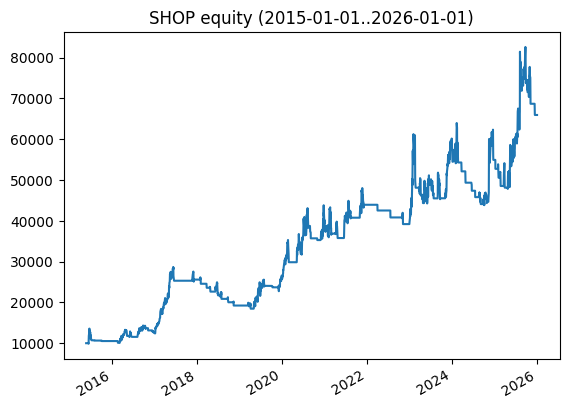

In [8]:
res.equity_curve.plot(title=f'{TICKER} equity ({START}..{END})');

## 5. Watch the bar-by-bar events (toggle on/off)

In [9]:
from agents.evaluator.logging_util import verbose

with verbose():                      # SIGNAL / BUY / SELL printed for this run only
    run_backtest(df, strat, ticker=TICKER, start=START, end=END)

SHOP   SIGNAL 2015-06-09 range_expansion  day_chg=+5.04%  box=8d/3.34%  close_range=93%  STRONG -> buy next open


SHOP   BUY  2015-06-10 @ 2.8450  stop=2.7312  (range_expansion)


SHOP   SELL 2015-06-19 @ 3.6330  ret=+27.70%  held=7d  (weakness)


SHOP   SIGNAL 2015-07-30 range_expansion  day_chg=+11.62%  box=5d/4.82%  close_range=35% -> buy next open


SHOP   BUY  2015-07-31 @ 3.8130  stop=3.7882  (range_expansion)


...

SHOP   BUY  2025-10-21 @ 164.7900  stop=158.1984  (range_expansion)


SHOP   SELL 2025-11-05 @ 158.1984  ret=-4.00%  held=11d  (stop_loss)


SHOP   SIGNAL 2025-12-10 range_expansion  day_chg=+5.33%  box=5d/4.04%  close_range=95%  STRONG -> buy next open


SHOP   BUY  2025-12-11 @ 167.4800  stop=160.7808  (range_expansion)


SHOP   SELL 2025-12-12 @ 160.7808  ret=-4.00%  held=1d  (stop_loss)


## 6. Compare against the batch lab oracle (optional)

In [10]:
sys.path.insert(0, str(root / 'agents' / 'base_breakout_strategy'))
from base_identification import find_ranges
import pandas as pd

batch = {pd.Timestamp(r.trade.buy.date): r.trade
         for r in find_ranges(df, box_pct=3.0, min_days=3, expansion_pct=4.0,
                              start_date=pd.Timestamp(START), end_date=pd.Timestamp(END))
         if r.trade and r.trade.sell is not None}
onbar = {t.entry_date: t for t in res.trades}

rows = []
for d in sorted(set(onbar) | set(batch)):
    ob, bt = onbar.get(d), batch.get(d)
    rows.append({
        
        'entry': d.date(),
        'onbar_reason': ob.exit_reason if ob else None,
        'onbar_ret': ob.return_pct if ob else None,
        'batch_reason': bt.sell_reason if bt else None,
        'batch_ret': bt.return_pct if bt else None,
    })
pd.DataFrame(rows)

,entry,onbar_reason,onbar_ret,batch_reason,batch_ret
0,2015-06-10,weakness,7.10,None,NaN
1,2015-07-31,stop_loss,-0.65,None,NaN
2,2015-10-01,stop_loss,-1.11,None,NaN
3,2016-02-17,stop_loss,-4.00,None,NaN
4,2016-03-03,weakness,16.58,None,NaN
...,...,...,...,...,...
56,2025-03-20,stop_loss,-0.84,None,NaN
57,2025-04-23,weakness,54.87,None,NaN
58,2025-10-06,stop_loss,-4.00,None,NaN
59,2025-10-21,stop_loss,-4.00,None,NaN


## 7. Slice the features vs returns

Every trade (`led` from section 3) carries the full feature set — including trades that *failed* a condition — so you can see what actually lines up with returns.

In [11]:
# slice ALL setups (led_all from the scan) by a few recorded features
la = led_all.assign(win=led_all['return_pct'] > 0)

print(f'population: {len(la)} setups')
print('\n— by Stage-2 pass count —')
print(la.groupby('stage2_pass_count')['return_pct'].agg(['count', 'mean', 'median']))

print('\n— price above ALL MAs (10/20 EMA, 50/200 SMA) at signal —')
print(la.groupby('above_all_mas')['return_pct'].agg(['count', 'mean']))

print('\n— above the 200-SMA at signal —')
print(la.groupby('above_200sma')['return_pct'].agg(['count', 'mean']))

print('\n— blue sky (no overhead supply, 12m) vs overhead —')
print(la.groupby('blue_sky_12m')['return_pct'].agg(['count', 'mean']))

population: 88 setups

— by Stage-2 pass count —
                   count       mean  median
stage2_pass_count                          
0                      4  -1.025000  -3.600
1                      3   5.883333  -1.110
2                      4   2.982500  -0.325
3                     15   4.643333  -1.940
4                     24  10.761667  -1.180
5                     28  -0.817857  -4.000
6                     10   0.795000  -4.000

— price above ALL MAs (10/20 EMA, 50/200 SMA) at signal —
               count      mean
above_all_mas                 
False             15  3.063333
True              68  4.038088

— above the 200-SMA at signal —
              count      mean
above_200sma                 
False             7  8.770000
True             76  3.409868

— blue sky (no overhead supply, 12m) vs overhead —
              count      mean
blue_sky_12m                 
False            62  4.422581
True             26  2.471538


In [12]:
# OPTIONAL — gate instead of record: require N of 6 Stage-2 checks to enter.
# Same features are recorded either way; this just filters which trades are taken.
for mc in (0, 4, 5, 6):
    r = run_backtest(df, StageRangeStrategy(box_pct=5.0, min_criteria=mc),
                     ticker=TICKER, start=START, end=END)
    print(f'min_criteria={mc}: {len(r.trades)} trades')

min_criteria=0: 24 trades


min_criteria=4: 19 trades


min_criteria=5: 13 trades

min_criteria=6: 3 trades
